# k-Means-Clusteranalyse – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/k-means-clusteranalyse)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Die **k-Means-Clusteranalyse** gruppiert Datenpunkte in **k Cluster** so, dass
die Summe der quadrierten Abstände zu den jeweiligen Cluster-Zentroiden minimiert wird.

**Algorithmus (5 Schritte):**
1. **k festlegen** – Anzahl der Cluster vorgeben
2. **Zentroiden initialisieren** – k zufällige Startpunkte
3. **Punkte zuordnen** – jeden Punkt dem nächsten Zentroid zuweisen
4. **Zentroiden aktualisieren** – Mittelpunkt jedes Clusters neu berechnen
5. **Wiederholen** – Schritte 3+4 bis keine Änderung mehr

**Zielfunktion (Within-Cluster Sum of Squares):**
$$WCSS = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

**Optimale k bestimmen:** Elbow-Methode (Ellenbogen-Methode)

**Eigenschaften:**
- Partitionierendes Verfahren (nicht hierarchisch)
- Geeignet für große Datensätze
- k muss vorab festgelegt werden
- Ergebnis hängt von Startpartition ab → numiqo: 10 Wiederholungen

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Der k-Means-Algorithmus – Schritt für Schritt

Wir zeigen alle 5 Schritte visuell an einem einfachen 2D-Datensatz (k=3).

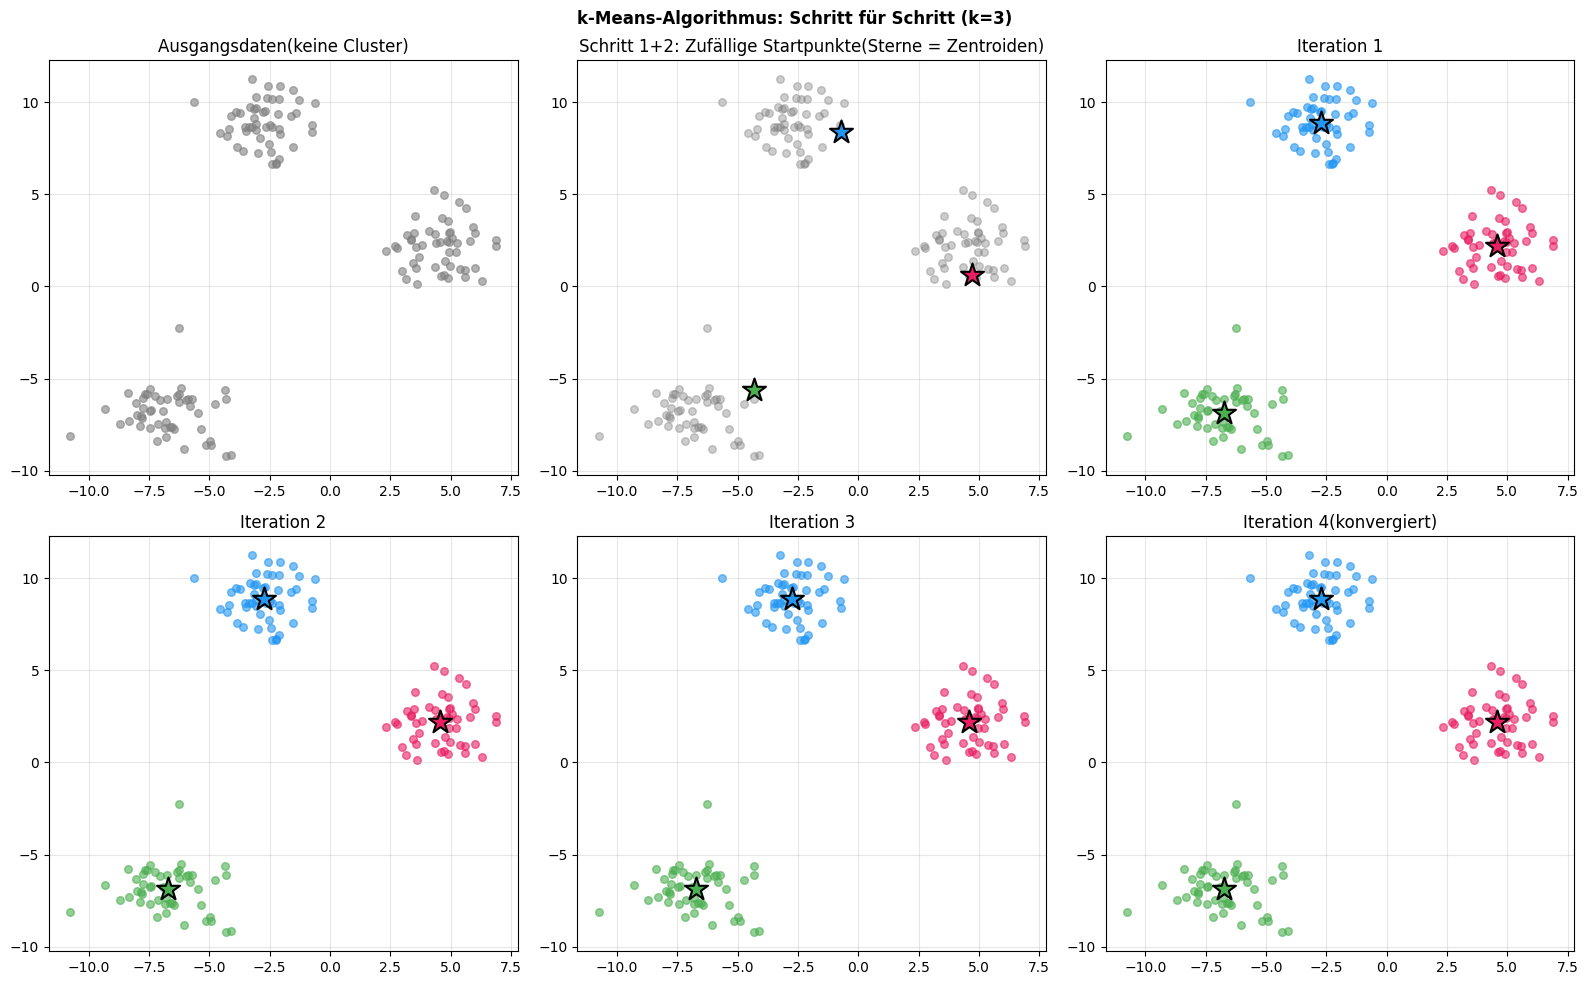

In [2]:
# Datensatz generieren (3 natuerliche Cluster)
np.random.seed(42)
X, y_true = make_blobs(n_samples=150, centers=3, cluster_std=1.2,
                       random_state=42)

# Manueller k-Means für Visualisierung
def kmeans_schritt(X, k, n_iter=4, seed=10):
    np.random.seed(seed)
    idx = np.random.choice(len(X), k, replace=False)
    zentroiden = X[idx].copy()
    verlauf = [zentroiden.copy()]
    labels_verlauf = []

    for _ in range(n_iter):
        dists = np.array([[np.linalg.norm(x - z) for z in zentroiden] for x in X])
        labels = dists.argmin(axis=1)
        labels_verlauf.append(labels.copy())
        for j in range(k):
            if (labels == j).sum() > 0:
                zentroiden[j] = X[labels == j].mean(axis=0)
        verlauf.append(zentroiden.copy())

    return verlauf, labels_verlauf

verlauf, labels_verlauf = kmeans_schritt(X, k=3, n_iter=4)

farben_k = ["#E91E63", "#2196F3", "#4CAF50"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("k-Means-Algorithmus: Schritt für Schritt (k=3)", fontsize=12,
             fontweight="bold")

# Schritt 0: Rohdaten
axes[0,0].scatter(X[:,0], X[:,1], color="gray", s=30, alpha=0.6)
axes[0,0].set_title("Ausgangsdaten(keine Cluster)")
axes[0,0].grid(alpha=0.3)

# Schritt 1: Zufällige Startpositionen
axes[0,1].scatter(X[:,0], X[:,1], color="gray", s=30, alpha=0.4)
for j, z in enumerate(verlauf[0]):
    axes[0,1].scatter(*z, color=farben_k[j], s=300, marker="*", zorder=5,
                      edgecolors="black", linewidth=1.5)
axes[0,1].set_title("Schritt 1+2: Zufällige Startpunkte(Sterne = Zentroiden)")
axes[0,1].grid(alpha=0.3)

# Schritte 3-4: Iterationen 1-4
for it, ax in zip([0, 1, 2, 3], [axes[0,2], axes[1,0], axes[1,1], axes[1,2]]):
    labels_it = labels_verlauf[it]
    for j in range(3):
        mask = labels_it == j
        ax.scatter(X[mask,0], X[mask,1], color=farben_k[j], s=30, alpha=0.6)
    for j, z in enumerate(verlauf[it+1]):
        ax.scatter(*z, color=farben_k[j], s=300, marker="*", zorder=5,
                   edgecolors="black", linewidth=1.5)
    ax.set_title("Iteration " + str(it+1) +
                 ("(konvergiert)" if it == 3 else ""))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Optimale Clusteranzahl: Elbow-Methode

Die **WCSS** (Within-Cluster Sum of Squares) sinkt mit jedem zusätzlichen Cluster.
Der **Ellenbogen** – der Punkt, ab dem der Abfall abflacht – zeigt das optimale k.

Elbow-Methode
k   WCSS
1   9959.2
2   2868.7 <- Elbow (optimales k)
3   408.4
4   349.7
5   300.7
6   256.2
7   222.1
8   190.5
9   164.6
10   149.7

Optimales k = 2


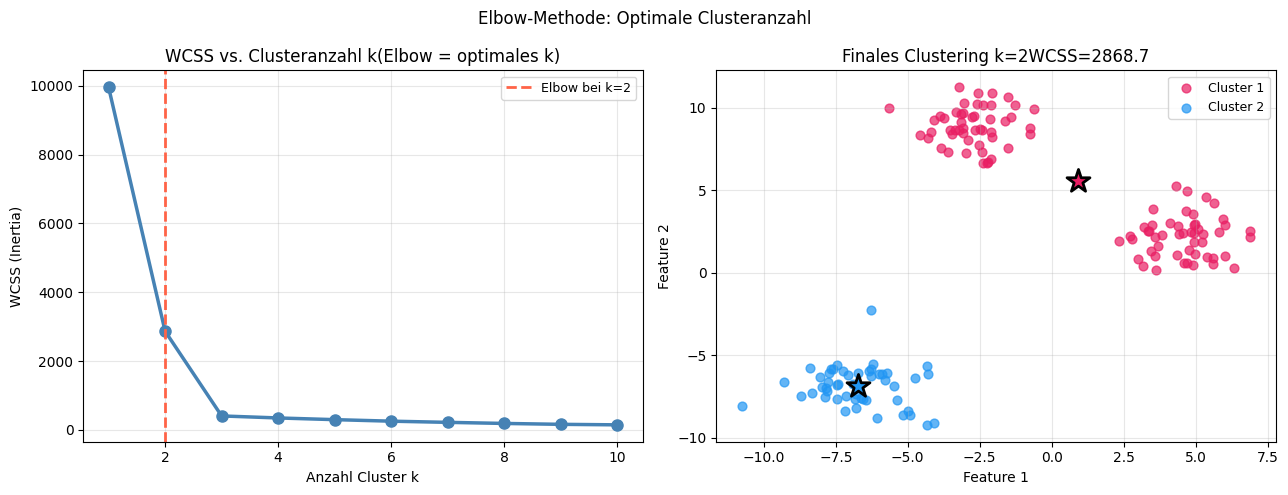

In [3]:
# Elbow-Methode
wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

# Elbow-Punkt finden (größte Abnahme der zweiten Ableitung)
diff1 = np.diff(wcss)
diff2 = np.diff(diff1)
elbow_k = int(np.argmax(np.abs(diff2)) + 2)

print("Elbow-Methode")
print("k   WCSS")
for k, w in zip(k_range, wcss):
    marker = " <- Elbow (optimales k)" if k == elbow_k else ""
    print(str(k) + "   " + str(round(w, 1)) + marker)
print()
print("Optimales k = " + str(elbow_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Elbow-Methode: Optimale Clusteranzahl", fontsize=12)

axes[0].plot(list(k_range), wcss, "o-", color="steelblue", linewidth=2.5,
             markersize=8)
axes[0].axvline(elbow_k, color="tomato", linestyle="--", linewidth=2,
                label="Elbow bei k=" + str(elbow_k))
axes[0].set_title("WCSS vs. Clusteranzahl k(Elbow = optimales k)")
axes[0].set_xlabel("Anzahl Cluster k")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Finales Clustering mit optimalem k
km_final = KMeans(n_clusters=elbow_k, random_state=42, n_init=10)
labels_final = km_final.fit_predict(X)
zentroiden_final = km_final.cluster_centers_

for j in range(elbow_k):
    mask = labels_final == j
    axes[1].scatter(X[mask,0], X[mask,1], color=farben_k[j], s=40, alpha=0.7,
                    label="Cluster " + str(j+1))
    axes[1].scatter(*zentroiden_final[j], color=farben_k[j], s=300, marker="*",
                    zorder=5, edgecolors="black", linewidth=2)
axes[1].set_title("Finales Clustering k=" + str(elbow_k) +
                  "WCSS=" + str(round(km_final.inertia_, 1)))
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Praxisbeispiel: Kundensegmentierung

**Fragestellung:** Welche Kundengruppen gibt es basierend auf
Alter und Kaufbetrag?

Dies ist ein typisches Marketing-Anwendungsbeispiel für k-Means.

Kundensegmentierung: k-Means (k=3)

Cluster  n   Mittl. Alter  Mittl. Kauf  Segment
1        56  59.1          153.2        Ältere Sparsamere
2        72  40.4          207.3        Mittleres Segment
3        72  24.6          79.8        Junge Kaufer


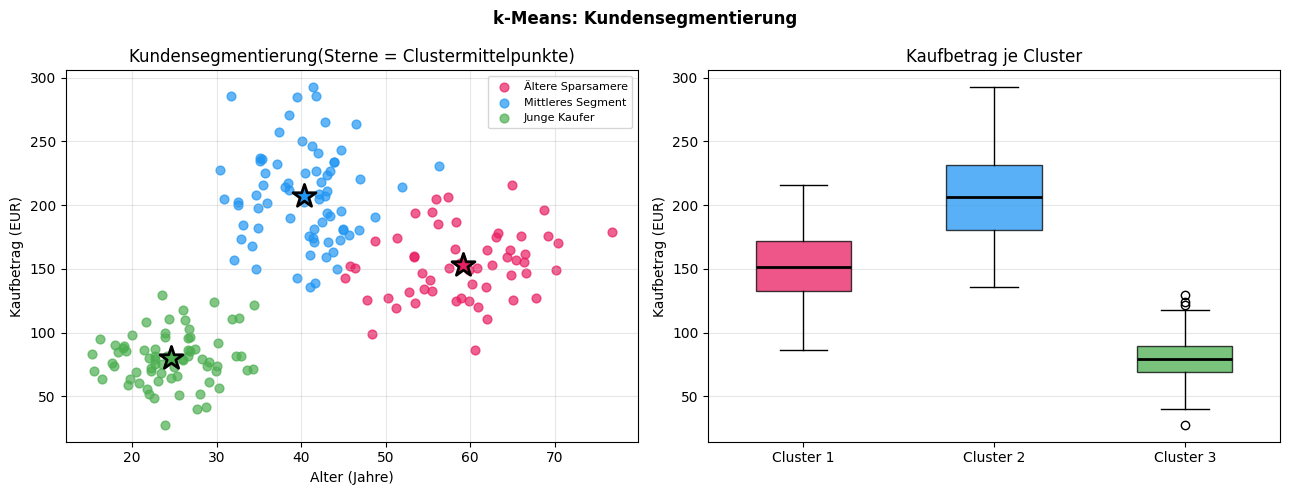

In [4]:
# Kundensegmentierung
np.random.seed(42)
n_kunden = 200

# 3 Kundengruppen simulieren
alter_jung   = np.random.normal(25, 5, 70)
kauf_jung    = np.random.normal(80, 20, 70)
alter_mittel = np.random.normal(40, 6, 80)
kauf_mittel  = np.random.normal(200, 40, 80)
alter_alt    = np.random.normal(60, 8, 50)
kauf_alt     = np.random.normal(150, 30, 50)

alter = np.concatenate([alter_jung, alter_mittel, alter_alt])
kauf  = np.concatenate([kauf_jung,  kauf_mittel,  kauf_alt])
X_kunden = np.column_stack([alter, kauf])

# Standardisierung (wichtig für k-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kunden)

# k-Means mit k=3
km_kunden = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k = km_kunden.fit_predict(X_scaled)
zentroiden_k = scaler.inverse_transform(km_kunden.cluster_centers_)

print("Kundensegmentierung: k-Means (k=3)")
print()
print("Cluster  n   Mittl. Alter  Mittl. Kauf  Segment")
segmente = {}
for j in range(3):
    mask = labels_k == j
    a_mw = alter[mask].mean()
    k_mw = kauf[mask].mean()
    n_j  = mask.sum()
    if a_mw < 35:
        seg = "Junge Kaufer"
    elif k_mw > 170:
        seg = "Mittleres Segment"
    else:
        seg = "Ältere Sparsamere"
    segmente[j] = seg
    print(str(j+1) + "        " + str(n_j) + "  " +
          str(round(a_mw, 1)) + "          " +
          str(round(k_mw, 1)) + "        " + seg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("k-Means: Kundensegmentierung", fontsize=12, fontweight="bold")

# Streudiagramm
for j in range(3):
    mask = labels_k == j
    axes[0].scatter(alter[mask], kauf[mask], color=farben_k[j],
                    s=40, alpha=0.7, label=segmente[j])
    axes[0].scatter(*zentroiden_k[j], color=farben_k[j], s=300, marker="*",
                    zorder=5, edgecolors="black", linewidth=2)
axes[0].set_title("Kundensegmentierung(Sterne = Clustermittelpunkte)")
axes[0].set_xlabel("Alter (Jahre)")
axes[0].set_ylabel("Kaufbetrag (EUR)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Cluster-Profile als Boxplot
import matplotlib.patches as mpatches
for j in range(3):
    mask = labels_k == j
    bp = axes[1].boxplot(kauf[mask], positions=[j+1], widths=0.5,
                         patch_artist=True,
                         medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor(farben_k[j])
    bp["boxes"][0].set_alpha(0.75)

axes[1].set_title("Kaufbetrag je Cluster")
axes[1].set_ylabel("Kaufbetrag (EUR)")
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["Cluster 1", "Cluster 2", "Cluster 3"])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Wichtig: Standardisierung vor k-Means

k-Means verwendet **euklidische Distanzen** – Variablen mit großem Wertebereich
dominieren die Cluster. Immer **z-standardisieren** vor der Analyse!

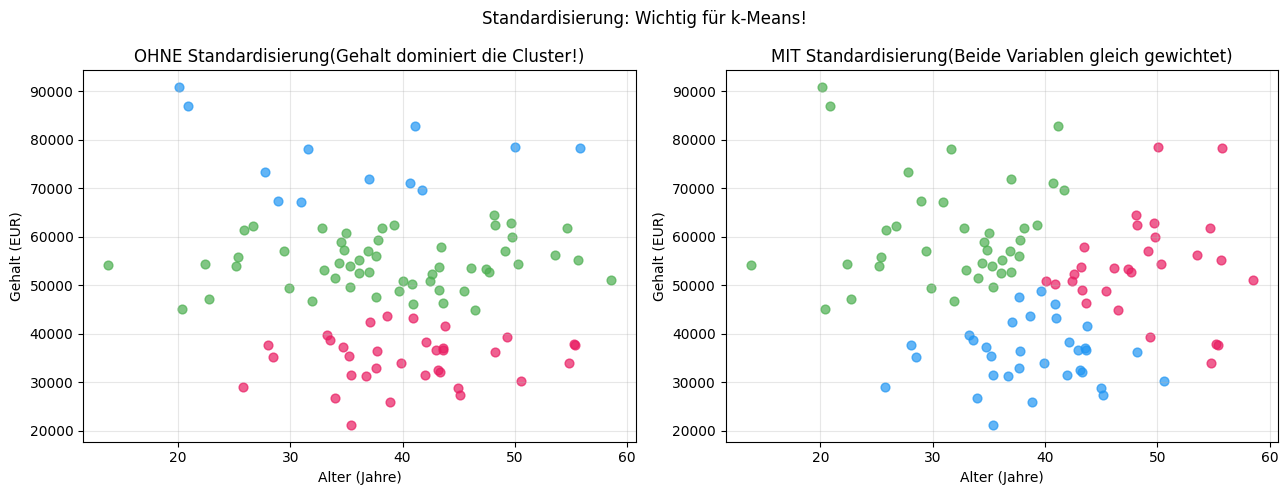

Fazit: Immer StandardScaler() vor KMeans() verwenden!
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)


In [5]:
# Standardisierung: vorher vs. nachher
np.random.seed(42)
alter_d = np.random.normal(40, 10, 100)
gehalt_d = np.random.normal(50000, 15000, 100)  # viel größere Skala!
X_d = np.column_stack([alter_d, gehalt_d])

# Ohne Standardisierung
km_ohne = KMeans(n_clusters=3, random_state=42, n_init=10)
lab_ohne = km_ohne.fit_predict(X_d)

# Mit Standardisierung
sc_d = StandardScaler()
X_d_scaled = sc_d.fit_transform(X_d)
km_mit = KMeans(n_clusters=3, random_state=42, n_init=10)
lab_mit = km_mit.fit_predict(X_d_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Standardisierung: Wichtig für k-Means!", fontsize=12)

for ax, labels, titel in [
    (axes[0], lab_ohne, "OHNE Standardisierung(Gehalt dominiert die Cluster!)"),
    (axes[1], lab_mit,  "MIT Standardisierung(Beide Variablen gleich gewichtet)")
]:
    for j in range(3):
        mask = labels == j
        ax.scatter(alter_d[mask], gehalt_d[mask], color=farben_k[j], s=40, alpha=0.7)
    ax.set_title(titel)
    ax.set_xlabel("Alter (Jahre)")
    ax.set_ylabel("Gehalt (EUR)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Fazit: Immer StandardScaler() vor KMeans() verwenden!")
print("from sklearn.preprocessing import StandardScaler")
print("X_scaled = StandardScaler().fit_transform(X)")

## 5. Zusammenfassung

```
k-Means-Clusteranalyse – Übersicht
│
├── WAS?
│   Partitionierendes Clusterverfahren
│   Teilt n Datenpunkte in k Cluster
│   Minimiert WCSS = Sum(||xi - mu_j||^2)
│
├── ALGORITHMUS (5 Schritte)
│   1. k festlegen
│   2. k zufällige Startzentroiden
│   3. Jeden Punkt dem nächsten Zentroid zuordnen
│   4. Neue Zentroiden = Mittelpunkt je Cluster
│   5. Schritt 3+4 wiederholen bis keine Änderung
│
├── OPTIMALES k: ELBOW-METHODE
│   WCSS für k=1,2,...,10 berechnen
│   "Knick" in der Kurve = optimales k
│
├── WICHTIG: STANDARDISIERUNG!
│   k-Means basiert auf euklid. Distanz
│   -> Variablen mit grossem Wertebereich dominieren
│   -> Immer StandardScaler() anwenden!
│
├── VORTEILE
│   Einfach, schnell, skalierbar
│   Gut für grosse Datenmengen
│
├── NACHTEILE
│   k muss vorab festgelegt werden
│   Ergebnis abhängig von Startpartition
│   Nur kugelförmige Cluster gut erkannt
│
└── PYTHON
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    X_scaled = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    zentroiden = km.cluster_centers_
    wcss = km.inertia_
```

---
Quelle: [numiqo.de/tutorial/k-means-clusteranalyse](https://numiqo.de/tutorial/k-means-clusteranalyse)